In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)


## Supply Chain Management Data Analysis 

In [4]:
df = pd.read_csv('Business_Operations_Analyst_data.csv')

In [5]:
df.head()

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,4893,4.766231,6.053952,3.840976,28701,16975,2778,228,26,83
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,4453,4.304335,3.886996,2.113929,36198,14052,1535,288,16,39
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,5956,1.030779,7.335160,4.211437,22784,9863,13435,153,3,49
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,5814,2.871244,1.393481,1.751671,13172,15911,14508,143,39,35
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,2279,4.060930,4.212666,4.231919,39619,19011,1904,296,30,67


In [6]:
df.shape

(500, 20)

In [7]:
df.dtypes

Warehouse_ID              object
Location                  object
Current_Stock              int64
Demand_Forecast            int64
Lead_Time_Days             int64
Shipping_Time_Days         int64
Stockout_Risk              int64
Operational_Cost           int64
Supplier_ID               object
Product_Category          object
Monthly_Sales              int64
Order_Processing_Time    float64
Return_Rate              float64
Customer_Rating          float64
Warehouse_Capacity         int64
Storage_Cost               int64
Transportation_Cost        int64
Backorder_Quantity         int64
Damaged_Goods              int64
Employee_Count             int64
dtype: object

In [8]:
df.columns

Index(['Warehouse_ID', 'Location', 'Current_Stock', 'Demand_Forecast',
       'Lead_Time_Days', 'Shipping_Time_Days', 'Stockout_Risk',
       'Operational_Cost', 'Supplier_ID', 'Product_Category', 'Monthly_Sales',
       'Order_Processing_Time', 'Return_Rate', 'Customer_Rating',
       'Warehouse_Capacity', 'Storage_Cost', 'Transportation_Cost',
       'Backorder_Quantity', 'Damaged_Goods', 'Employee_Count'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Warehouse_ID           500 non-null    object 
 1   Location               500 non-null    object 
 2   Current_Stock          500 non-null    int64  
 3   Demand_Forecast        500 non-null    int64  
 4   Lead_Time_Days         500 non-null    int64  
 5   Shipping_Time_Days     500 non-null    int64  
 6   Stockout_Risk          500 non-null    int64  
 7   Operational_Cost       500 non-null    int64  
 8   Supplier_ID            500 non-null    object 
 9   Product_Category       500 non-null    object 
 10  Monthly_Sales          500 non-null    int64  
 11  Order_Processing_Time  500 non-null    float64
 12  Return_Rate            500 non-null    float64
 13  Customer_Rating        500 non-null    float64
 14  Warehouse_Capacity     500 non-null    int64  
 15  Storag

In [10]:
#Checking Null Values 
df.isnull().sum()

Warehouse_ID             0
Location                 0
Current_Stock            0
Demand_Forecast          0
Lead_Time_Days           0
Shipping_Time_Days       0
Stockout_Risk            0
Operational_Cost         0
Supplier_ID              0
Product_Category         0
Monthly_Sales            0
Order_Processing_Time    0
Return_Rate              0
Customer_Rating          0
Warehouse_Capacity       0
Storage_Cost             0
Transportation_Cost      0
Backorder_Quantity       0
Damaged_Goods            0
Employee_Count           0
dtype: int64

In [11]:
#Checking Duplicate Values 
df.duplicated().sum()

np.int64(0)

In [12]:
#Numerical Features
numerical_feature = [ feature for feature in df.columns if df[feature].dtype !='O']
print("Numerical Features are: ",numerical_feature,'\n Count of numerical features: ',len(numerical_feature))

Numerical Features are:  ['Current_Stock', 'Demand_Forecast', 'Lead_Time_Days', 'Shipping_Time_Days', 'Stockout_Risk', 'Operational_Cost', 'Monthly_Sales', 'Order_Processing_Time', 'Return_Rate', 'Customer_Rating', 'Warehouse_Capacity', 'Storage_Cost', 'Transportation_Cost', 'Backorder_Quantity', 'Damaged_Goods', 'Employee_Count'] 
 Count of numerical features:  16


In [13]:
#Cateforical Features
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'O']
print("Categorical Feature: ",categorical_feature,"\n Countof categorical feature: ",len(categorical_feature))

Categorical Feature:  ['Warehouse_ID', 'Location', 'Supplier_ID', 'Product_Category'] 
 Countof categorical feature:  4


In [14]:
# Checking Statistical Summmary of the dataset 
df.describe()

,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,2722.822000,2957.050000,5.958000,3.948000,14.944000,65886.354000,5335.572000,2.750462,5.229366,3.090865,30032.818000,10263.83400,8001.086000,147.380000,24.684000,52.810000
std,1314.878786,1398.763988,2.630223,1.921635,5.923431,20283.576821,2619.353688,1.262967,2.661448,1.156971,11921.277948,5584.14567,4269.354045,87.880656,14.868298,27.888087
min,519.000000,402.000000,2.000000,1.000000,5.000000,30165.000000,1004.000000,0.505159,0.506755,1.004825,10338.000000,1083.00000,515.000000,0.000000,0.000000,5.000000
25%,1565.250000,1745.750000,4.000000,2.000000,10.000000,48731.750000,2978.000000,1.644623,3.085484,2.073853,19486.750000,5335.75000,4294.500000,71.750000,11.000000,28.000000
50%,2670.000000,3094.000000,6.000000,4.000000,15.000000,65733.500000,5234.000000,2.817771,5.128133,3.148014,29862.500000,10023.00000,7973.000000,141.000000,25.000000,53.000000
75%,3842.750000,4152.500000,8.000000,6.000000,20.000000,82900.250000,7550.750000,3.782273,7.406404,4.137274,40692.250000,15162.00000,11857.000000,224.000000,37.000000,78.000000
max,4998.000000,5200.000000,10.000000,7.000000,25.000000,99965.000000,9931.000000,4.954139,9.992465,4.998258,49979.000000,19979.00000,14988.000000,300.000000,50.000000,100.000000


In [15]:
# Creating copy of the dataset
df_copy = df.copy()

In [16]:
df_copy[[ 'Warehouse_ID', 'Product_Category', 'Location','Supplier_ID']] = df_copy[[ 'Warehouse_ID', 'Product_Category', 'Location','Supplier_ID']].astype('object')

# Feature Engineering 

In [17]:
# Feature Engineering

# 1. Inventory Turnover
df_copy['Inventory_Turnover'] = df_copy['Monthly_Sales'] / df_copy['Current_Stock']

# 2. Delivery Efficiency
df_copy['Delivery_Efficiency'] = df_copy['Shipping_Time_Days'] + df_copy['Order_Processing_Time']

# 3. Total Cost
df_copy['Total_Cost'] = df_copy['Operational_Cost'] + df_copy['Storage_Cost'] + df_copy['Transportation_Cost']

# 4. Estimated Profit
df_copy['Estimated_Profit'] = df_copy['Monthly_Sales'] - df_copy['Total_Cost']

# 5. Stock Utilization
df_copy['Stock_Utilization'] = df_copy['Current_Stock'] / df_copy['Warehouse_Capacity']

# 6. Demand Gap
df_copy['Demand_Gap'] = df_copy['Demand_Forecast'] - df_copy['Current_Stock']

# 7. Risk Score
df_copy['Risk_Score'] = df_copy['Stockout_Risk'] + df_copy['Return_Rate'] + df_copy['Damaged_Goods']


In [18]:
df_copy[['Inventory_Turnover','Delivery_Efficiency','Total_Cost','Estimated_Profit','Stock_Utilization','Demand_Gap','Risk_Score']].shape


(500, 7)

In [19]:
df_copy.shape

(500, 27)

In [20]:
df_copy.columns

Index(['Warehouse_ID', 'Location', 'Current_Stock', 'Demand_Forecast',
       'Lead_Time_Days', 'Shipping_Time_Days', 'Stockout_Risk',
       'Operational_Cost', 'Supplier_ID', 'Product_Category', 'Monthly_Sales',
       'Order_Processing_Time', 'Return_Rate', 'Customer_Rating',
       'Warehouse_Capacity', 'Storage_Cost', 'Transportation_Cost',
       'Backorder_Quantity', 'Damaged_Goods', 'Employee_Count',
       'Inventory_Turnover', 'Delivery_Efficiency', 'Total_Cost',
       'Estimated_Profit', 'Stock_Utilization', 'Demand_Gap', 'Risk_Score'],
      dtype='object')

In [21]:
# Data Cleaning & Preprocessing

# 1. Handle Missing Values
print("Missing values per column:")
print(df_copy.isnull().sum())

# 2. Remove Duplicates
duplicates_count = df_copy.duplicated().sum()
print(f"\nNumber of duplicate rows before removal: {duplicates_count}")
if duplicates_count > 0:
    df_copy = df_copy.drop_duplicates()
    print("Duplicates removed.")

# 3. Fix Incorrect Data Types
for col in ['Location', 'Product_Category', 'Supplier_ID']:
    df_copy[col] = df_copy[col].astype('category')
print("\nIncorrect data types fixed (Categorical columns converted to 'category' type).")

# 4. Detect and Treat Outliers using the IQR Method
def detect_and_cap_outliers(df, columns):
    df_treated = df.copy()
    print("\nOutlier Detection & Capping (IQR Method):")
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        
        print(f"Column '{col}': found {outlier_count} outliers (Bounds: [{lower_bound:.2f}, {upper_bound:.2f}])")
        
        # Cap outliers
        df_treated[col] = df_treated[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_treated

cols_to_check = ['Inventory_Turnover', 'Stock_Utilization']
df_copy = detect_and_cap_outliers(df_copy, cols_to_check)
print("\nOutlier treatment complete. Extreme values capped at 1.5 * IQR bounds.")


Missing values per column:
Warehouse_ID             0
Location                 0
Current_Stock            0
Demand_Forecast          0
Lead_Time_Days           0
Shipping_Time_Days       0
Stockout_Risk            0
Operational_Cost         0
Supplier_ID              0
Product_Category         0
Monthly_Sales            0
Order_Processing_Time    0
Return_Rate              0
Customer_Rating          0
Warehouse_Capacity       0
Storage_Cost             0
Transportation_Cost      0
Backorder_Quantity       0
Damaged_Goods            0
Employee_Count           0
Inventory_Turnover       0
Delivery_Efficiency      0
Total_Cost               0
Estimated_Profit         0
Stock_Utilization        0
Demand_Gap               0
Risk_Score               0
dtype: int64

Number of duplicate rows before removal: 0

Incorrect data types fixed (Categorical columns converted to 'category' type).

Outlier Detection & Capping (IQR Method):
Column 'Inventory_Turnover': found 44 outliers (Bounds: [-1.87, 

### Exploratory Data Analysis - Supply Chain Management System 

In [22]:
df_copy.duplicated().sum()

np.int64(0)

In [23]:
numerical_feature = [feature for feature in df_copy.columns if df_copy[feature].dtypes !='O' and  df_copy[feature].dtypes !='category']
numerical_feature

['Current_Stock',
 'Demand_Forecast',
 'Lead_Time_Days',
 'Shipping_Time_Days',
 'Stockout_Risk',
 'Operational_Cost',
 'Monthly_Sales',
 'Order_Processing_Time',
 'Return_Rate',
 'Customer_Rating',
 'Warehouse_Capacity',
 'Storage_Cost',
 'Transportation_Cost',
 'Backorder_Quantity',
 'Damaged_Goods',
 'Employee_Count',
 'Inventory_Turnover',
 'Delivery_Efficiency',
 'Total_Cost',
 'Estimated_Profit',
 'Stock_Utilization',
 'Demand_Gap',
 'Risk_Score']

In [24]:
df_copy[numerical_feature]

,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count,Inventory_Turnover,Delivery_Efficiency,Total_Cost,Estimated_Profit,Stock_Utilization,Demand_Gap,Risk_Score
0,3926,484,8,3,7,93895,4893,4.766231,6.053952,3.840976,28701,16975,2778,228,26,83,1.246307,7.766231,113648,-108755,0.136790,-3442,39.053952
1,3032,5122,3,6,25,46847,4453,4.304335,3.886996,2.113929,36198,14052,1535,288,16,39,1.468668,10.304335,62434,-57981,0.083762,2090,44.886996
2,4763,4343,5,5,16,64176,5956,1.030779,7.335160,4.211437,22784,9863,13435,153,3,49,1.250472,6.030779,87474,-81518,0.209050,-420,26.335160
3,2219,777,7,6,15,38940,5814,2.871244,1.393481,1.751671,13172,15911,14508,143,39,35,2.620099,8.871244,69359,-63545,0.168463,-1442,55.393481
4,809,4756,2,7,16,33933,2279,4.060930,4.212666,4.231919,39619,19011,1904,296,30,67,2.817058,11.060930,54848,-52569,0.020419,3947,50.212666
5,3840,666,9,1,19,30165,1326,0.660006,2.411436,1.110988,32490,9766,807,181,17,20,0.345313,1.660006,40738,-39412,0.118190,-3174,38.411436
6,4757,4776,7,7,12,38284,6186,3.084797,4.195066,1.010432,19414,6995,8901,237,25,94,1.300399,10.084797,54180,-47994,0.245029,19,41.195066
7,4803,2432,9,5,20,45299,5539,2.433820,6.010139,2.449832,42401,17954,13519,172,9,91,1.153238,7.433820,76772,-71233,0.113276,-2371,35.010139
8,1401,2940,10,6,22,36265,1822,1.291656,3.147318,4.739127,18053,17284,773,205,17,78,1.300500,7.291656,54322,-52500,0.077605,1539,42.147318
9,4213,3732,5,7,20,57333,4608,3.099240,3.218994,2.698893,31286,5653,7017,97,44,58,1.093757,10.099240,70003,-65395,0.134661,-481,67.218994


<Axes: >

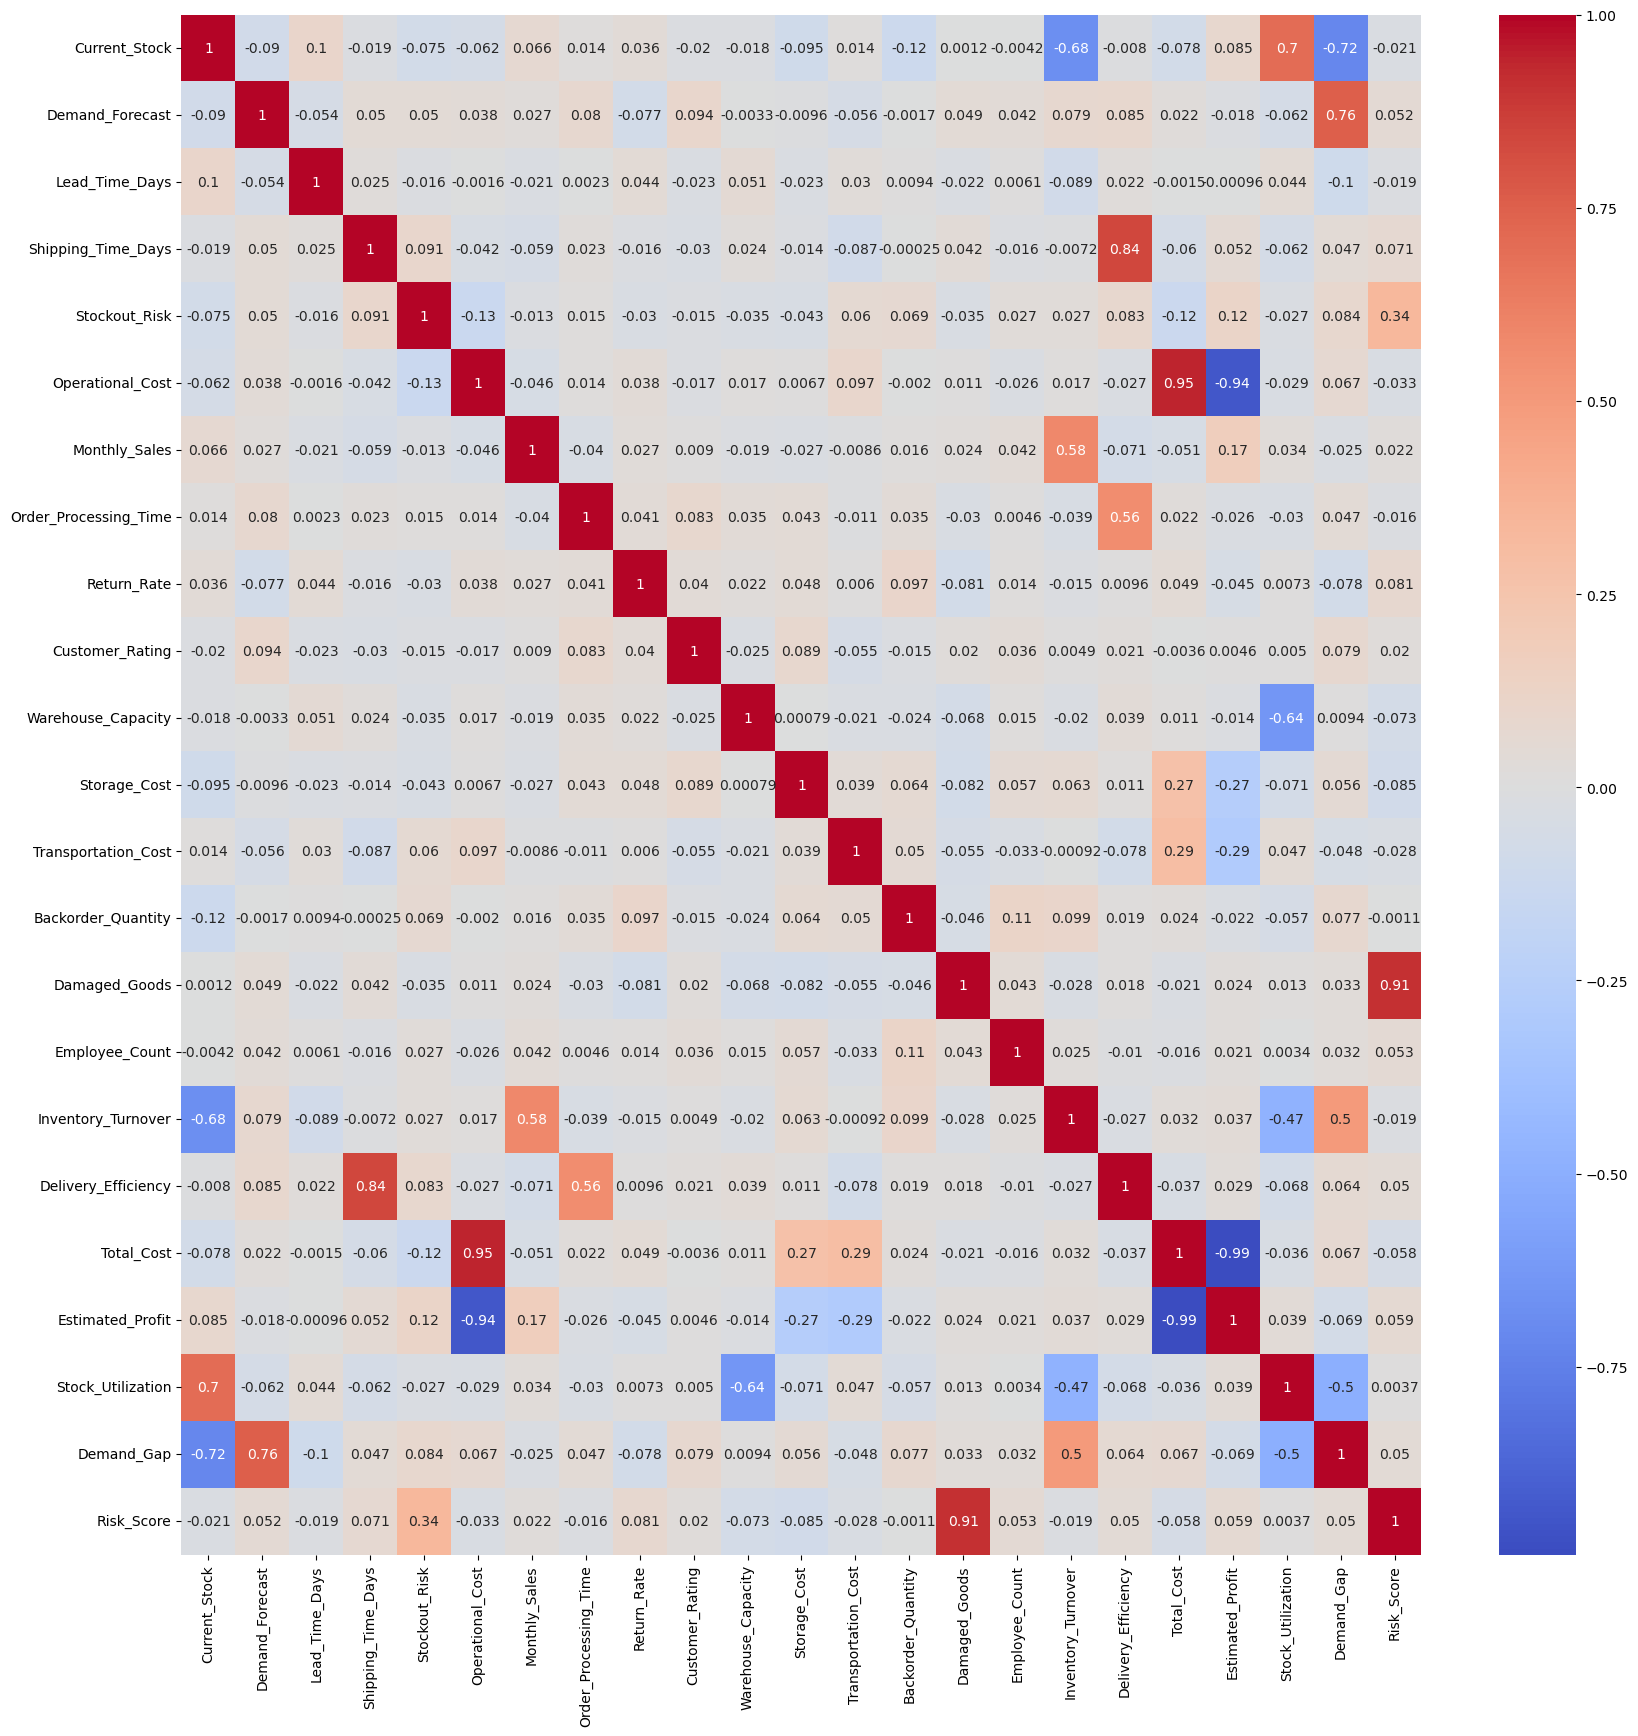

In [25]:
plt.figure(figsize=(20,20))
sns.heatmap(df_copy[numerical_feature].corr(),annot=True, cmap='coolwarm')

#### Insights :

1. As current stock increase, the Stock Utilization also tends to increase by 67%.

2. There is a 76% of demand gap in demand forecasting. 

3. 84% delivery of products is delivered at correct shipping time.

4. 34% risk score indicating that stockout is slightly increases.

5. 95% of total cost is spend in operational cost.

6. 50% increament in monthly sales indicate tends to increase 50% growth in inventory turnover.

In [26]:
df_copy.columns

Index(['Warehouse_ID', 'Location', 'Current_Stock', 'Demand_Forecast',
       'Lead_Time_Days', 'Shipping_Time_Days', 'Stockout_Risk',
       'Operational_Cost', 'Supplier_ID', 'Product_Category', 'Monthly_Sales',
       'Order_Processing_Time', 'Return_Rate', 'Customer_Rating',
       'Warehouse_Capacity', 'Storage_Cost', 'Transportation_Cost',
       'Backorder_Quantity', 'Damaged_Goods', 'Employee_Count',
       'Inventory_Turnover', 'Delivery_Efficiency', 'Total_Cost',
       'Estimated_Profit', 'Stock_Utilization', 'Demand_Gap', 'Risk_Score'],
      dtype='object')

In [27]:
#Top 5 Warehouses by Monthly Sales, location and employee count.
df.groupby(['Warehouse_ID','Location','Employee_Count'])['Monthly_Sales'].sum().sort_values(ascending=False).head(5)

Warehouse_ID  Location     Employee_Count
WH131         Denver       14                9931
WH304         Los Angeles  45                9928
WH287         Atlanta      97                9883
WH319         New York     41                9874
WH491         Houston      58                9864
Name: Monthly_Sales, dtype: int64

#### Warehouse WH131 have highest monthly sales and least employee based on denver location. (Monthly Sales - 9931)

In [28]:
#Top5 products category by monthly sales
df.groupby('Product_Category')['Monthly_Sales'].sum().sort_values(ascending=False).head(5)

Product_Category
Apparel        564991
Electronics    560057
Groceries      541821
Furniture      516458
Automotive     484459
Name: Monthly_Sales, dtype: int64

##### Apparel product category generate high monthly sales of rupee 5.64k

In [29]:
df_copy['Risk_Score'].unique()

array([39.053952  , 44.8869958 , 26.33516014, 55.39348149, 50.21266613,
       38.4114358 , 41.19506579, 35.01013879, 42.14731756, 67.21899357,
       38.94978987, 51.91569564, 36.45949963, 68.93318924, 64.02251725,
       31.22702068, 30.93176923, 73.02957084, 34.96139695, 27.43619075,
       29.0166861 , 32.72699726, 46.82637324, 67.23914205, 20.85912655,
       52.4804228 , 26.70797661, 30.15212028, 39.30076197, 38.85728737,
       52.3109219 , 30.38394044, 32.64895731, 57.69218548, 30.62837128,
       48.66335029, 33.73309823, 32.61958336, 67.15714845, 53.51614842,
       63.52644573, 39.92727106, 20.62530604, 44.93082655, 33.52368481,
       71.64084092, 35.46494495, 57.22895001, 55.93858294, 41.04356617,
       65.13285074, 53.18630819, 47.76144958, 20.84237285, 12.86212708,
       35.00207599, 42.06171209, 58.68499521, 42.5153645 , 33.02274291,
       44.20440986, 58.34292436, 21.33685323, 66.75678751, 25.17362441,
       22.07033553, 62.3117482 , 47.37881364, 47.47424861, 39.38

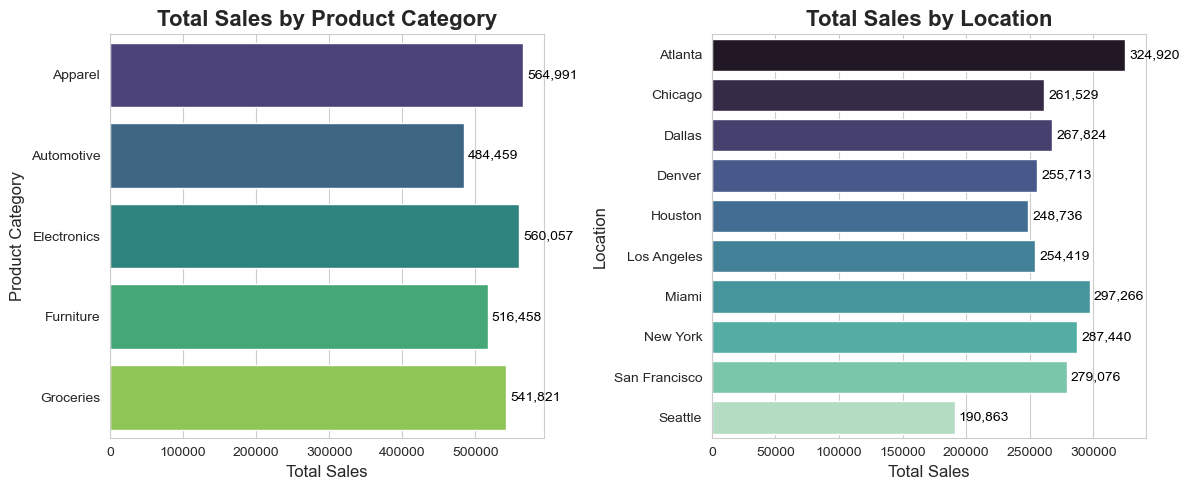

In [30]:
# Sales Trends
plt.figure(figsize=(12,5))
sns.set_style("whitegrid")

#Sales by Product Category
plt.subplot(1, 2, 1)
sales_by_cat = df_copy.groupby('Product_Category', observed=False)['Monthly_Sales'].sum().sort_values(ascending=False).reset_index()
ax= sns.barplot(data=sales_by_cat, x='Monthly_Sales', y='Product_Category', palette='viridis', hue='Product_Category', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10, color='black')
plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

#Sales by Location
plt.subplot(1, 2, 2)
sales_by_loc = df_copy.groupby('Location', observed=False)['Monthly_Sales'].sum().sort_values(ascending=False).reset_index()
ax = sns.barplot(data=sales_by_loc, x='Monthly_Sales', y='Location', palette='mako', hue='Location', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10, color='black')   
plt.title('Total Sales by Location', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Location', fontsize=12)

plt.tight_layout()
plt.show()


#### **Sales Trends Insights:**
1. **Product Category**: The **Apparel** category leads in monthly sales (approx. 565K), closely followed by **Electronics** (560K) and **Groceries** (541K). **Automotive** generated the lowest sales at 484K.

2. **Geographic Performance**: Sales are relatively evenly distributed across the 10 major metropolitan locations, showing that the customer base is geographically diverse.


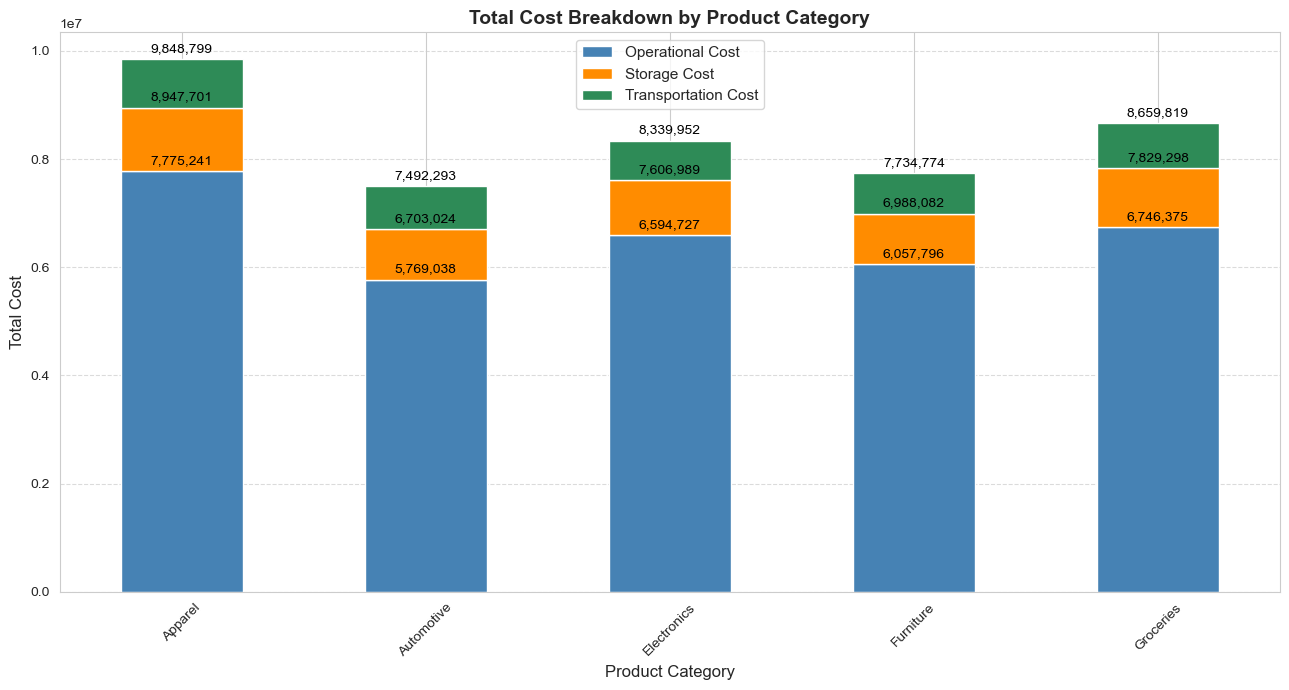

In [31]:
# Visualization 2: Cost Analysis
cost_breakdown = df_copy.groupby('Product_Category', observed=False)[['Operational_Cost', 'Storage_Cost', 'Transportation_Cost']].sum().reset_index()

# Plot stacked bars
ax =cost_breakdown.set_index('Product_Category').plot(kind='bar', stacked=True, color=['#4682B4', '#FF8C00', '#2E8B57'], figsize=(13, 7))
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10, color='black')
plt.title('Total Cost Breakdown by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Cost', fontsize=12)
plt.xticks(rotation=45)
plt.legend(['Operational Cost', 'Storage Cost', 'Transportation Cost'], fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### **Cost Analysis Insights:**
1. **Cost Domination**: Operational costs dominate the total expense structure, making up over **90%** of the total cost for all categories. Storage and transportation costs, while significant in absolute terms, are much smaller fractions.

2. **Profitability Concern**: The total operational expenses for every product category are in the millions, while monthly sales are in the hundreds of thousands. This massive cost mismatch explains why estimated profit margins are negative across the board. Scaling down operational overhead is the most critical step to achieving profitability.


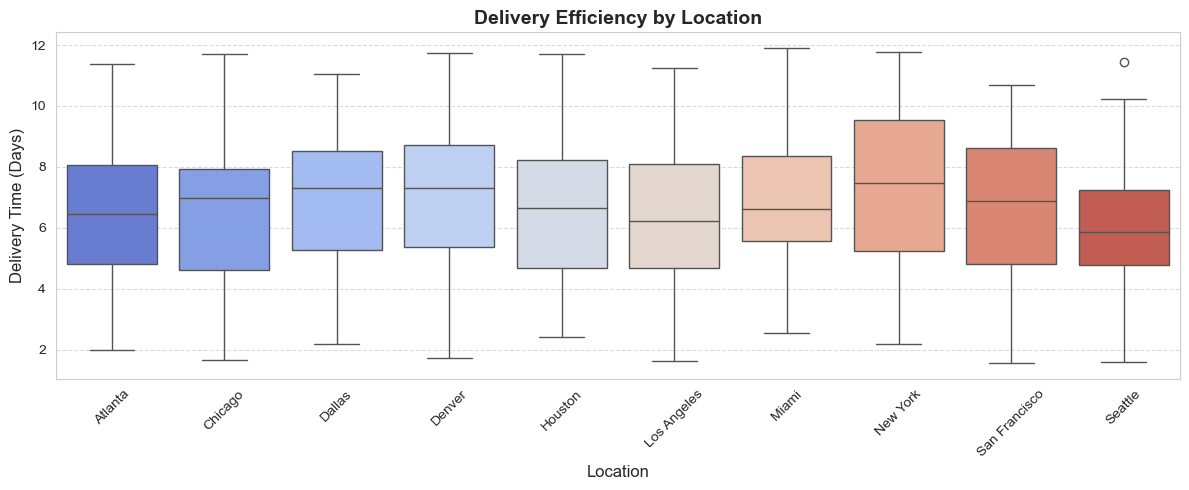

In [32]:
#Delivery Performance
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_copy, x='Location', y='Delivery_Efficiency', palette='coolwarm', hue='Location', legend=False)
plt.title('Delivery Efficiency by Location', fontsize=14, fontweight='bold')
plt.xlabel('Location', fontsize=12)
plt.ylabel('Delivery Time (Days)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### **Delivery Performance Insights:**
1. **Delivery Bottlenecks**: Locations like **Miami**, **New York**, and **Dallas** exhibit higher median delivery times, exceeding 7–8 days.

2.  **Process Efficiency**: A lower value is better. By optimizing order processing times (which range from 0.5 to 5 days) and negotiating faster shipping contracts, warehouses can significantly reduce delivery cycle times.


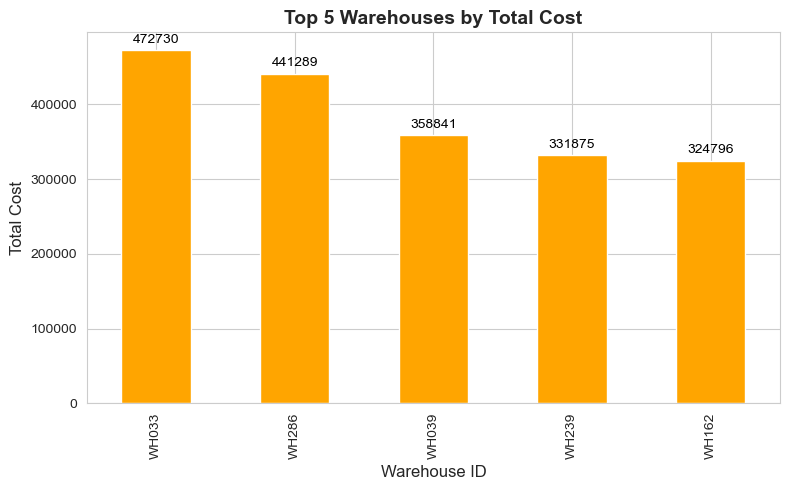

In [33]:
#Top warehouse by total cost 
warehouse_total_cost=df_copy.groupby('Warehouse_ID', observed=False)['Total_Cost'].sum().sort_values(ascending=False).head(5)
ax = warehouse_total_cost.plot(kind='bar', color='orange', figsize=(8, 5))
for container in ax.containers:
    ax.bar_label(container,padding=3,fontsize=10, color='black')
plt.title('Top 5 Warehouses by Total Cost', fontsize=14, fontweight='bold')
plt.xlabel('Warehouse ID', fontsize=12)     
plt.ylabel('Total Cost', fontsize=12)
plt.tight_layout()
plt.show()

### Warehouse By Total Cosr
1. **WH033** has highest total cost.
2. **WH162** has lowest total cost.

In [34]:
df_copy.columns

Index(['Warehouse_ID', 'Location', 'Current_Stock', 'Demand_Forecast',
       'Lead_Time_Days', 'Shipping_Time_Days', 'Stockout_Risk',
       'Operational_Cost', 'Supplier_ID', 'Product_Category', 'Monthly_Sales',
       'Order_Processing_Time', 'Return_Rate', 'Customer_Rating',
       'Warehouse_Capacity', 'Storage_Cost', 'Transportation_Cost',
       'Backorder_Quantity', 'Damaged_Goods', 'Employee_Count',
       'Inventory_Turnover', 'Delivery_Efficiency', 'Total_Cost',
       'Estimated_Profit', 'Stock_Utilization', 'Demand_Gap', 'Risk_Score'],
      dtype='object')

<Figure size 2000x600 with 0 Axes>

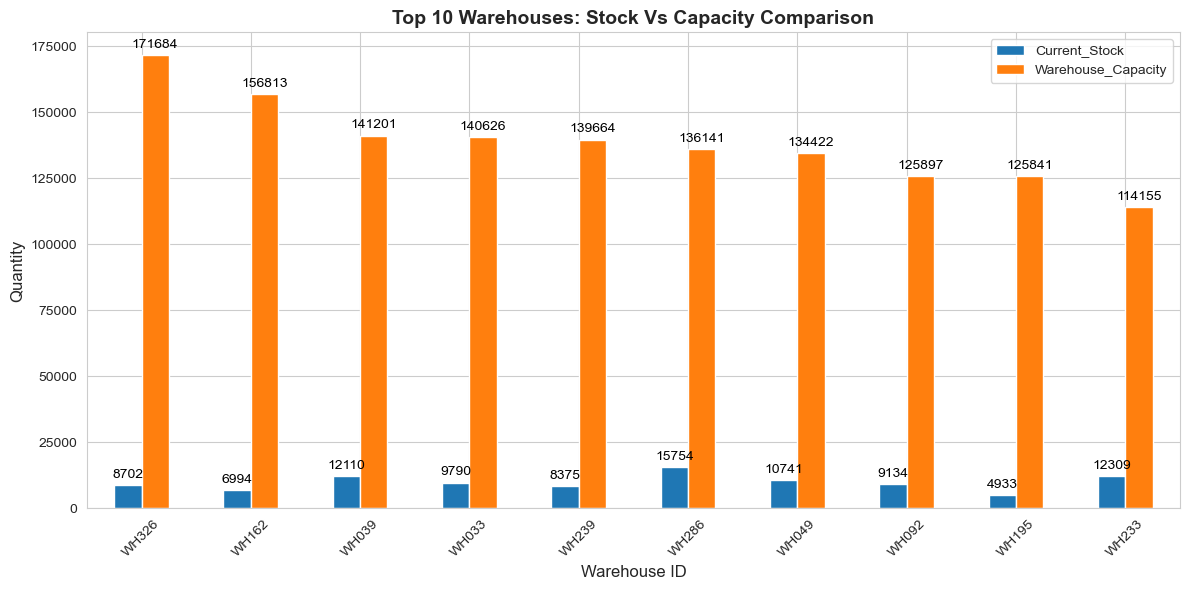

In [35]:
#Top 10 Stock utilization and warehouse capacity comparison 
warehouse_stock_capacity = df_copy.groupby('Warehouse_ID', observed=False)[['Current_Stock','Warehouse_Capacity']].sum().sort_values(by='Warehouse_Capacity', ascending=False).head(10)
plt.figure(figsize=(20, 6))
ax = warehouse_stock_capacity.plot(kind='bar', color=['#1f77b4', '#ff7f0e'], figsize=(12, 6))
for conatiner in ax.containers:
    ax.bar_label(conatiner, label_type='edge', fontsize=10, color='black',padding = 3 )
plt.title("Top 10 Warehouses: Stock Vs Capacity Comparison",fontsize=14, fontweight='bold')
plt.xlabel("Warehouse ID", fontsize=12)
plt.ylabel("Quantity", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
df_copy.groupby('Warehouse_ID', observed=False)[['Current_Stock','Warehouse_Capacity']].sum().sort_values(by='Warehouse_Capacity', ascending=False).head(10)

,Current_Stock,Warehouse_Capacity
Warehouse_ID,,
WH326,8702,171684
WH162,6994,156813
WH039,12110,141201
WH033,9790,140626
WH239,8375,139664
WH286,15754,136141
WH049,10741,134422
WH092,9134,125897
WH195,4933,125841


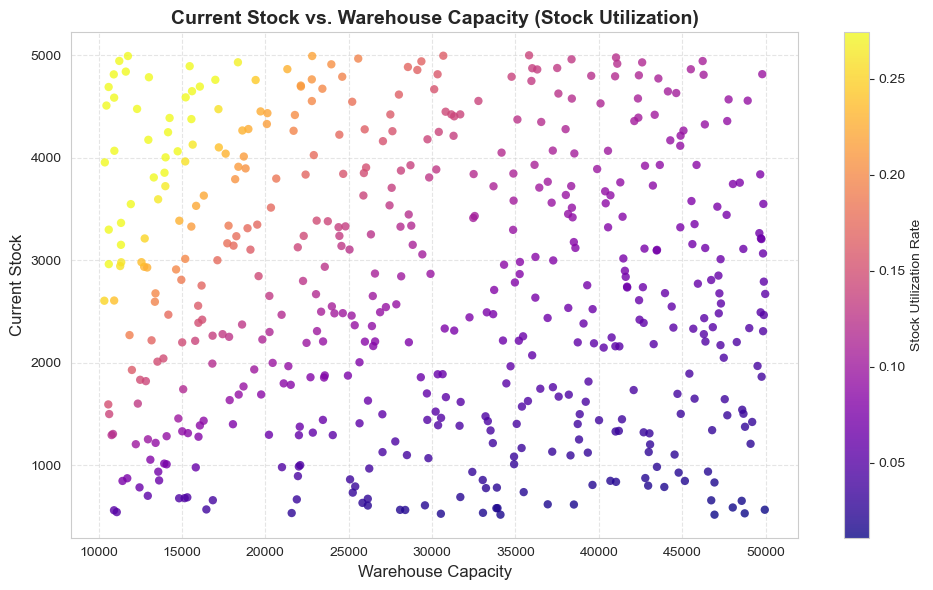

In [37]:
# Visualization 4: Inventory Distribution
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_copy['Warehouse_Capacity'], df_copy['Current_Stock'], c=df_copy['Stock_Utilization'], cmap='plasma', alpha=0.8, edgecolor='none')
plt.colorbar(scatter, label='Stock Utilization Rate')
plt.title('Current Stock vs. Warehouse Capacity (Stock Utilization)', fontsize=14, fontweight='bold')
plt.xlabel('Warehouse Capacity', fontsize=12)
plt.ylabel('Current Stock', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### **Inventory Distribution Insights:**
1. **Underutilization**: Across almost all warehouses, the stock utilization rate is extremely low (mostly under 20%, with a maximum of ~44%).

2. **Overcapacity**: Many warehouses have capacities up to 50,000 units but hold less than 5,000 units in stock. This indicates massive overcapacity, leading to unnecessarily high storage and operational maintenance costs. Right-sizing warehouse capacity or consolidating storage could yield major cost savings.


### **Executive Summary & Business Insights**

1. **Severe Profitability Deficit**: Every single record in the dataset shows a negative estimated profit margin. The total operational cost alone is several times larger than the monthly sales, indicating that the current cost structure is completely unsustainable.

2. **Excessive Storage Capacity**: Stock utilization rates are below 44% everywhere (averaging ~15%). The company is paying for huge warehouses (capacities up to 50,000 units) but only storing a fraction of that (typically 1,000 - 5,000 units).

3. **Delivery Efficiency**: Shipping and processing times combined range from 1.5 to nearly 12 days. The significant variance indicates inconsistent warehouse processes, particularly in order processing times.

4. **Demand Forecast Gaps**: There are substantial gaps where the demand forecast exceeds current stock, indicating high potential for stockout situations in high-demand periods.


### **Operational & Strategic Recommendations**

1. **Operational Cost Reduction**: Since operational cost makes up over 90% of total costs, audit warehouse staffing, utilities, and management expenses to locate and eliminate waste.

2. **Warehouse Consolidation**: Consolidate inventory from multiple underutilized warehouses into fewer, highly utilized hubs. This will dramatically reduce rental, storage, and utility costs.

3. **Standardize Order Processing**: Implement warehouse automation or improved workflows to reduce order processing times, which currently add up to 5 days of delay before shipping even starts.

4. **Demand-Driven Replenishment**: Align current stock levels more closely with the `Demand_Forecast` to avoid both stockouts (understocking) and overstocking.


In [38]:
# Export clean and feature-engineered datasets
# Cleaned dataset (without engineered features and outliers)
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
df_clean.to_csv('cleaned_dataset.csv', index=False)

# Feature engineered dataset (with engineered features and treated outliers)
df_copy.to_csv('feature_engineered_dataset.csv', index=False)


## Detailed Business Insights 

In [39]:
# Load dataset
df = pd.read_csv('feature_engineered_dataset.csv')


#### **Section 1: Sales Performance (Revenue & Growth)**
1. Which warehouse generates the highest monthly sales?
2. Which location contributes the highest sales?
3. Which product category generates the most sales?
4. What are the top 5 performing warehouses?
5. What are the bottom 5 performing warehouses?
6.   Which warehouse has the highest sales per employee?


1. Highest Monthly Sales Warehouse: WH131 (Denver) with 9,931
2. Location with Highest Sales: Atlanta with 324,920
3. Product Category with Most Sales: Apparel with 564,991

4. Top 5 Performing Warehouses by Sales:
   - Warehouse WH100 (Los Angeles): 18,312
   - Warehouse WH225 (San Francisco): 16,801
   - Warehouse WH258 (Miami): 15,440
   - Warehouse WH178 (Atlanta): 15,109
   - Warehouse WH404 (Atlanta): 14,855

5. Bottom 5 Performing Warehouses by Sales:
   - Warehouse WH492 (Dallas): 1,004
   - Warehouse WH407 (New York): 1,013
   - Warehouse WH136 (New York): 1,038
   - Warehouse WH026 (Los Angeles): 1,051
   - Warehouse WH395 (Dallas): 1,101

6. Highest Sales per Employee Warehouse: WH168 (Atlanta) with 1934.80 per employee


C:\Users\sujal_sahu\AppData\Local\Temp\ipykernel_7124\1521711440.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(x=top_5_warehouses.values, y=[f'WH {wh} ({loc})' for wh, loc in top_5_warehouses.index], palette='viridis')


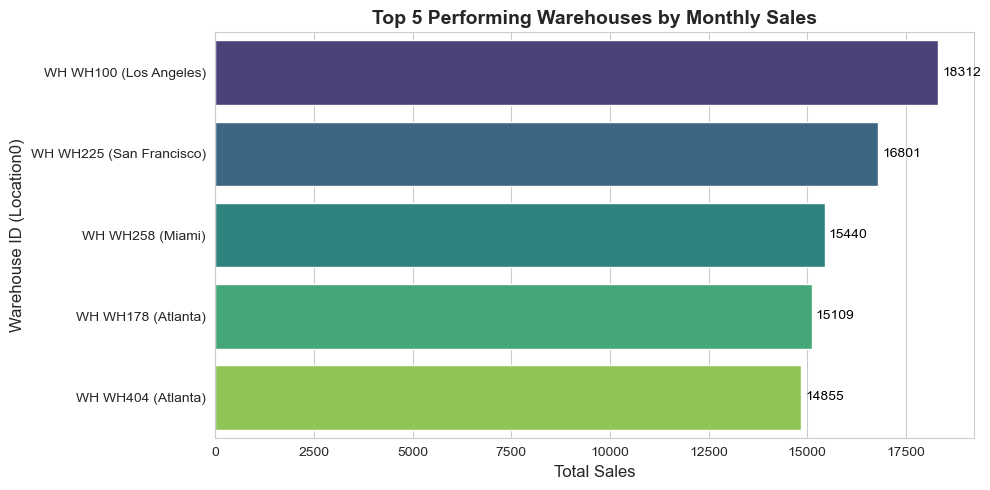

In [40]:
# 1. Highest sales warehouse
highest_sales_wh = df.loc[df['Monthly_Sales'].idxmax()]
print(f'1. Highest Monthly Sales Warehouse: {highest_sales_wh["Warehouse_ID"]} ({highest_sales_wh["Location"]}) with {highest_sales_wh["Monthly_Sales"]:,}')

# 2. Highest sales location
sales_by_loc = df.groupby('Location')['Monthly_Sales'].sum()
print(f'2. Location with Highest Sales: {sales_by_loc.idxmax()} with {sales_by_loc.max():,}')

# 3. Highest sales product category
sales_by_cat = df.groupby('Product_Category')['Monthly_Sales'].sum()
print(f'3. Product Category with Most Sales: {sales_by_cat.idxmax()} with {sales_by_cat.max():,}')

# 4. Top 5 performing warehouses
print('\n4. Top 5 Performing Warehouses by Sales:')
top_5_warehouses = df.groupby(['Warehouse_ID', 'Location'])['Monthly_Sales'].sum().sort_values(ascending=False).head(5)
for (wh, loc), val in top_5_warehouses.items():
    print(f'   - Warehouse {wh} ({loc}): {val:,}')

# 5. Bottom 5 performing warehouses
print('\n5. Bottom 5 Performing Warehouses by Sales:')
bottom_5_warehouses = df.groupby(['Warehouse_ID', 'Location'])['Monthly_Sales'].sum().sort_values(ascending=True).head(5)
for (wh, loc), val in bottom_5_warehouses.items():
    print(f'   - Warehouse {wh} ({loc}): {val:,}')

# 6. Highest sales per employee
df['Sales_Per_Employee'] = df['Monthly_Sales'] / df['Employee_Count']
highest_spe = df.loc[df['Sales_Per_Employee'].idxmax()]
print(f'\n6. Highest Sales per Employee Warehouse: {highest_spe["Warehouse_ID"]} ({highest_spe["Location"]}) with {highest_spe["Sales_Per_Employee"]:.2f} per employee')

# Visual 1: Sales Performance
plt.figure(figsize=(10, 5))
ax= sns.barplot(x=top_5_warehouses.values, y=[f'WH {wh} ({loc})' for wh, loc in top_5_warehouses.index], palette='viridis')
for container in ax.containers:
    ax.bar_label(container, padding = 3, fontsize=10, color='black')
plt.title('Top 5 Performing Warehouses by Monthly Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Warehouse ID (Location0)', fontsize=12)
plt.tight_layout()
plt.show()


In [41]:
df['Sales_Per_Employee'] = df['Monthly_Sales'] / df['Employee_Count']
highest_spe = df.loc[df['Sales_Per_Employee'].idxmax()]
print(f"\nHighest Sales per employee : {highest_spe['Warehouse_ID']} ({highest_spe['Location']}) with {highest_spe['Sales_Per_Employee']:.1f}")
highest_spe


Highest Sales per employee : WH168 (Atlanta) with 1934.8


Warehouse_ID                 WH168
Location                   Atlanta
Current_Stock                 1294
Demand_Forecast               2072
Lead_Time_Days                   3
Shipping_Time_Days               5
Stockout_Risk                   25
Operational_Cost             85680
Supplier_ID                   S717
Product_Category         Furniture
Monthly_Sales                 9674
Order_Processing_Time     2.007513
Return_Rate               5.766949
Customer_Rating           3.037074
Warehouse_Capacity           22010
Storage_Cost                 14540
Transportation_Cost          12286
Backorder_Quantity             105
Damaged_Goods                   13
Employee_Count                   5
Inventory_Turnover        6.159581
Delivery_Efficiency       7.007513
Total_Cost                  112506
Estimated_Profit           -102832
Stock_Utilization         0.058791
Demand_Gap                     778
Risk_Score               43.766949
Sales_Per_Employee          1934.8
Name: 98, dtype: obj

#### **Section 2: Inventory Management (Stock Optimization)**
1. Which warehouses have the highest inventory turnover?
2. Which warehouses are overstocked?
3. Which warehouses are understocked?
4. Which warehouses have the highest stock utilization?
5. Which warehouses are closest to capacity limits?
6. Which product categories require inventory replenishment?


Top 5 Warehouses by Inventory Turnover:
   - Warehouse WH010 (Atlanta): 6.16
   - Warehouse WH342 (Los Angeles): 6.16
   - Warehouse WH039 (Miami): 6.16
   - Warehouse WH043 (Miami): 6.16
   - Warehouse WH022 (Dallas): 6.16

Overstocked records: 225 out of 500 records

Understocked records: 275 out of 500 records

Top 5 Warehouses by Stock Utilization:
   - Warehouse WH001 (Miami): 27.43%
   - Warehouse WH002 (San Francisco): 27.43%
   - Warehouse WH387 (Los Angeles): 27.43%
   - Warehouse WH396 (Los Angeles): 27.43%
   - Warehouse WH399 (Denver): 27.43%

Warehouse Closest to Capacity: WH WH196 (Houston) at 27.43% utilization

Replenishment Needs by Product Category (Total Demand Gap):
   - Electronics: Demand Gap = 35,806 units
   - Automotive: Demand Gap = 26,915 units
   - Apparel: Demand Gap = 19,225 units
   - Furniture: Demand Gap = 17,759 units
   - Groceries: Demand Gap = 17,409 units


C:\Users\sujal_sahu\AppData\Local\Temp\ipykernel_7124\2392152907.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product_Category', y='Inventory_Turnover', palette='mako')


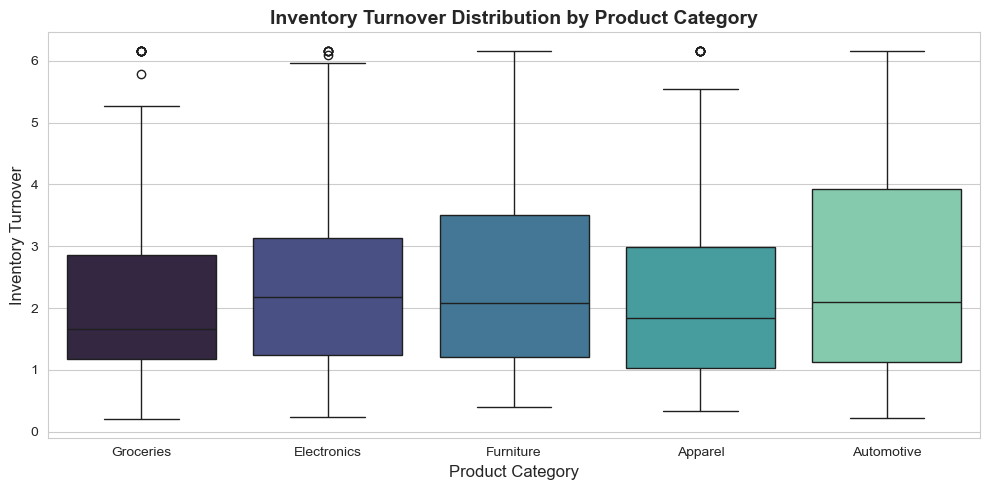

In [42]:
# 1. Highest inventory turnover
print('Top 5 Warehouses by Inventory Turnover:')
top_turnover = df.groupby(['Warehouse_ID', 'Location'])['Inventory_Turnover'].mean().sort_values(ascending=False).head(5)
for (wh, loc), val in top_turnover.items():
    print(f'   - Warehouse {wh} ({loc}): {val:.2f}')

# 2. Overstocked (Stock > Demand Forecast)
overstocked = df[df['Current_Stock'] > df['Demand_Forecast']]
print(f'\nOverstocked records: {len(overstocked)} out of {len(df)} records')

# 3. Understocked (Stock < Demand Forecast)
understocked = df[df['Current_Stock'] < df['Demand_Forecast']]
print(f'\nUnderstocked records: {len(understocked)} out of {len(df)} records')

# 4. Highest stock utilization
print('\nTop 5 Warehouses by Stock Utilization:')
top_util = df.groupby(['Warehouse_ID', 'Location'])['Stock_Utilization'].mean().sort_values(ascending=False).head(5)
for (wh, loc), val in top_util.items():
    print(f'   - Warehouse {wh} ({loc}): {val*100:.2f}%')

# 5. Closest to capacity limit
closest_cap = df.loc[df['Stock_Utilization'].idxmax()]
print(f'\nWarehouse Closest to Capacity: WH {closest_cap["Warehouse_ID"]} ({closest_cap["Location"]}) at {closest_cap["Stock_Utilization"]*100:.2f}% utilization')

# 6. Replenishment categories (positive Demand Gap)
print('\nReplenishment Needs by Product Category (Total Demand Gap):')
rep_cat = df.groupby('Product_Category', observed=False)['Demand_Gap'].sum().sort_values(ascending=False)
for cat, val in rep_cat.items():
    print(f'   - {cat}: Demand Gap = {val:,} units')

# Visual 2: Inventory Turnover by Product Category
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Product_Category', y='Inventory_Turnover', palette='mako')
plt.title('Inventory Turnover Distribution by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Inventory Turnover', fontsize=12)
plt.tight_layout()
plt.show()


#### **Section 3: Demand Forecasting (Demand Planning)**
1. Is current stock sufficient to meet forecasted demand?
2. Which warehouses have the largest demand gap?
3. Which locations have demand exceeding inventory?
4. Which products show the highest future demand?


Overall stock sufficiency: Current Stock = 1,361,411 units, Demand Forecast = 1,478,525 units
Is stock sufficient overall? No (Shortage: 117,114 units)

Top 5 Warehouses with Largest Demand Gaps:
   - Warehouse WH486 (Seattle): Gap = 5,916 units
   - Warehouse WH258 (Miami): Gap = 5,757 units
   - Warehouse WH187 (Dallas): Gap = 5,181 units
   - Warehouse WH178 (Atlanta): Gap = 5,096 units
   - Warehouse WH211 (Dallas): Gap = 4,575 units

Locations where Demand Exceeds Inventory (Net Gap > 0):
   - Houston: Exceeds by 40,398 units
   - Miami: Exceeds by 28,317 units
   - Atlanta: Exceeds by 18,138 units
   - San Francisco: Exceeds by 17,000 units
   - Seattle: Exceeds by 12,761 units
   - Denver: Exceeds by 6,254 units
   - New York: Exceeds by 5,790 units

Future Demand Forecast by Product Category:
   - Apparel: Forecasted Demand = 320,878 units
   - Groceries: Forecasted Demand = 314,006 units
   - Electronics: Forecasted Demand = 310,806 units
   - Furniture: Forecasted Demand = 27

C:\Users\sujal_sahu\AppData\Local\Temp\ipykernel_7124\277897401.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_gaps.values, y=loc_gaps.index, palette='coolwarm')


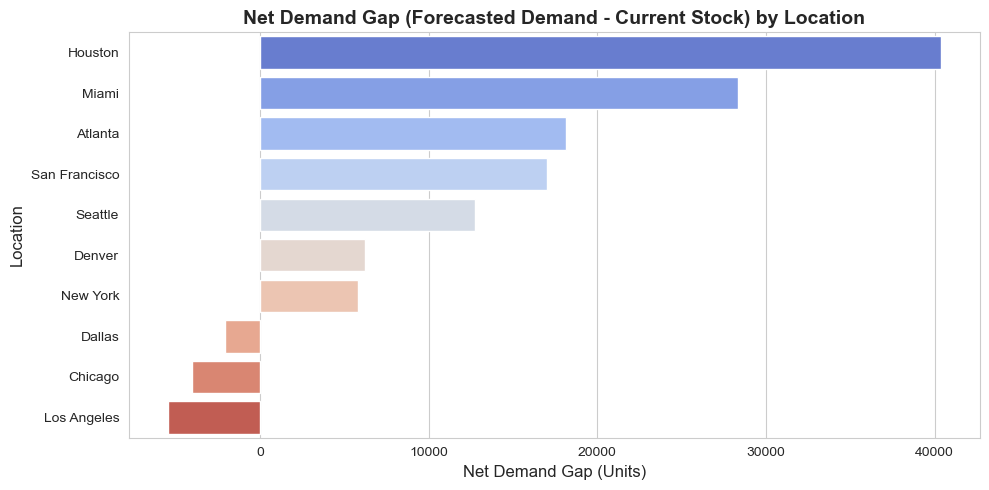

In [43]:
# 1. Sufficiency
total_stock = df['Current_Stock'].sum()
total_demand = df['Demand_Forecast'].sum()
print(f'Overall stock sufficiency: Current Stock = {total_stock:,} units, Demand Forecast = {total_demand:,} units')
print(f'Is stock sufficient overall? {"Yes" if total_stock >= total_demand else "No"} (Shortage: {total_demand - total_stock:,} units)')

# 2. Largest demand gap warehouses
print('\nTop 5 Warehouses with Largest Demand Gaps:')
top_gap_wh = df.groupby(['Warehouse_ID', 'Location'])['Demand_Gap'].sum().sort_values(ascending=False).head(5)
for (wh, loc), val in top_gap_wh.items():
    print(f'   - Warehouse {wh} ({loc}): Gap = {val:,} units')

# 3. Locations where demand exceeds inventory
print('\nLocations where Demand Exceeds Inventory (Net Gap > 0):')
loc_gaps = df.groupby('Location')['Demand_Gap'].sum().sort_values(ascending=False)
for loc, val in loc_gaps.items():
    if val > 0:
        print(f'   - {loc}: Exceeds by {val:,} units')

# 4. Products with highest future demand
print('\nFuture Demand Forecast by Product Category:')
prod_demand = df.groupby('Product_Category', observed=False)['Demand_Forecast'].sum().sort_values(ascending=False)
for cat, val in prod_demand.items():
    print(f'   - {cat}: Forecasted Demand = {val:,} units')

# Visual 3: Demand Gaps by Location
plt.figure(figsize=(10, 5))
sns.barplot(x=loc_gaps.values, y=loc_gaps.index, palette='coolwarm')
plt.title('Net Demand Gap (Forecasted Demand - Current Stock) by Location', fontsize=14, fontweight='bold')
plt.xlabel('Net Demand Gap (Units)', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.tight_layout()
plt.show()


#### **Section 4: Delivery Performance (Logistics Efficiency)**
1. Which warehouses have the longest shipping times?
2. Which warehouses have the highest order processing times?
3. Which warehouses are most delayed?
4. Which warehouses have the best delivery efficiency?
5. Which locations experience the most delivery delays?


Top 5 Warehouses with Longest Shipping Times: 
   - Warehouse WH001 (Chicago): 7.0 days
   - Warehouse WH472 (New York): 7.0 days
   - Warehouse WH417 (Denver): 7.0 days
   - Warehouse WH023 (San Francisco): 7.0 days
   - Warehouse WH473 (Atlanta): 7.0 days

Top 5 Warehouses with Longest Order Processing Times: 
   - Warehouse WH286 (Dallas): 5.0 days
   - Warehouse WH113 (Houston): 4.9 days
   - Warehouse WH381 (Los Angeles): 4.9 days
   - Warehouse WH192 (Los Angeles): 4.9 days
   - Warehouse WH387 (Atlanta): 4.9 days

Top 5 Most Delayed Warehouses (Longest Total Delivery Cycles):
   - Warehouse WH286 (Miami): 11.90 days
   - Warehouse WH434 (New York): 11.76 days
   - Warehouse WH307 (Denver): 11.74 days
   - Warehouse WH382 (Miami): 11.73 days
   - Warehouse WH414 (Chicago): 11.71 days

Top 5 Most Efficient Warehouses (Shortest Total Delivery Cycles):
   - Warehouse WH031 (San Francisco): 1.57 days
   - Warehouse WH484 (Los Angeles): 1.64 days
   - Warehouse WH182 (Chicago): 1.66 d

C:\Users\sujal_sahu\AppData\Local\Temp\ipykernel_7124\3735283789.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_delays.values, y=loc_delays.index, palette='flare')


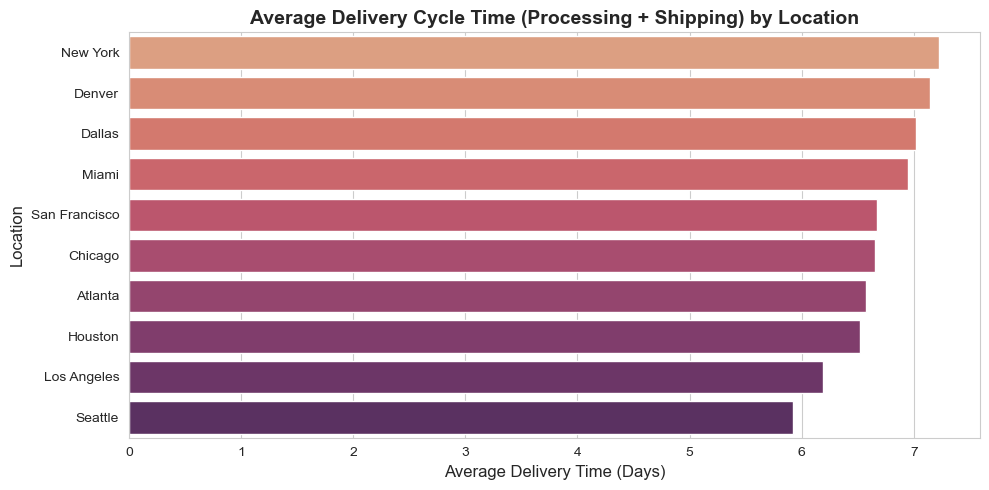

In [44]:
#Longest shipping times

print('Top 5 Warehouses with Longest Shipping Times: ')
long_ship = df.groupby(['Warehouse_ID', 'Location'])['Shipping_Time_Days'].mean().sort_values(ascending=False).head(5)
for (wh, loc), val in long_ship.items():
    print(f'   - Warehouse {wh} ({loc}): {val} days')

#Longest processing times
print('\nTop 5 Warehouses with Longest Order Processing Times: ')
long_proc = df.groupby(['Warehouse_ID', 'Location'])['Order_Processing_Time'].mean().sort_values(ascending=False).head(5)
for (wh, loc), val in long_proc.items():
    print(f'   - Warehouse {wh} ({loc}): {val:.1f} days')

# 3. Most delayed (Avg Delivery_Efficiency)
print('\nTop 5 Most Delayed Warehouses (Longest Total Delivery Cycles):')
most_delayed = df.groupby(['Warehouse_ID', 'Location'])['Delivery_Efficiency'].mean().sort_values(ascending=False).head(5)
for (wh, loc), val in most_delayed.items():
    print(f'   - Warehouse {wh} ({loc}): {val:.2f} days')

# 4. Best delivery efficiency
print('\nTop 5 Most Efficient Warehouses (Shortest Total Delivery Cycles):')
best_deliv = df.groupby(['Warehouse_ID', 'Location'])['Delivery_Efficiency'].mean().sort_values(ascending=True).head(5)
for (wh, loc), val in best_deliv.items():
    print(f'   - Warehouse {wh} ({loc}): {val:.2f} days')

# 5. Locations experiencing most delays
print('\nLocations by Average Delivery Cycle Time:')
loc_delays = df.groupby('Location')['Delivery_Efficiency'].mean().sort_values(ascending=False)
for loc, val in loc_delays.items():
    print(f'   - {loc}: {val:.2f} days')

# Visual 4: Delivery Efficiency by Location
plt.figure(figsize=(10, 5))
sns.barplot(x=loc_delays.values, y=loc_delays.index, palette='flare')
plt.title('Average Delivery Cycle Time (Processing + Shipping) by Location', fontsize=14, fontweight='bold')
plt.xlabel('Average Delivery Time (Days)', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.tight_layout()
plt.show()


#### **Section 5: Cost Analysis (Expense Optimization)**
1. Which warehouse has the highest operational cost?
2. Which warehouse has the highest transportation cost?
3. Which warehouse has the highest storage cost?
4. Which warehouse incurs the highest total cost?
5. What cost component contributes most to overall expenses?


Highest Operational Cost Warehouse: WH WH033 (Seattle) with 99,965
Highest Transportation Cost Warehouse: WH WH057 (Los Angeles) with 14,988
Highest Storage Cost Warehouse: WH WH257 (Houston) with 19,979
Highest Total Cost Warehouse: WH WH324 (Los Angeles) with 132,412

Cost Breakdown Contribution:
   - Operational Cost: 32,943,177 (78.30%)
   - Storage Cost:     5,131,917 (12.20%)
   - Transportation Cost: 4,000,543 (9.51%)


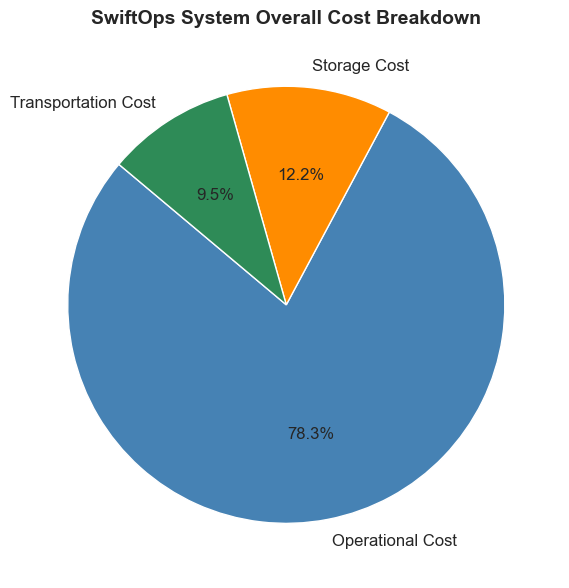

In [45]:
# 1. Highest operational cost
highest_op = df.loc[df['Operational_Cost'].idxmax()]
print(f'Highest Operational Cost Warehouse: WH {highest_op["Warehouse_ID"]} ({highest_op["Location"]}) with {highest_op["Operational_Cost"]:,}')

# 2. Highest transportation cost
highest_trans = df.loc[df['Transportation_Cost'].idxmax()]
print(f'Highest Transportation Cost Warehouse: WH {highest_trans["Warehouse_ID"]} ({highest_trans["Location"]}) with {highest_trans["Transportation_Cost"]:,}')

# 3. Highest storage cost
highest_stor = df.loc[df['Storage_Cost'].idxmax()]
print(f'Highest Storage Cost Warehouse: WH {highest_stor["Warehouse_ID"]} ({highest_stor["Location"]}) with {highest_stor["Storage_Cost"]:,}')

# 4. Highest total cost
highest_tc = df.loc[df['Total_Cost'].idxmax()]
print(f'Highest Total Cost Warehouse: WH {highest_tc["Warehouse_ID"]} ({highest_tc["Location"]}) with {highest_tc["Total_Cost"]:,}')

# 5. Cost component contribution
total_op = df['Operational_Cost'].sum()
total_stor = df['Storage_Cost'].sum()
total_trans = df['Transportation_Cost'].sum()
total_overall = df['Total_Cost'].sum()
print(f'\nCost Breakdown Contribution:')
print(f'   - Operational Cost: {total_op:,} ({total_op/total_overall*100:.2f}%)')
print(f'   - Storage Cost:     {total_stor:,} ({total_stor/total_overall*100:.2f}%)')
print(f'   - Transportation Cost: {total_trans:,} ({total_trans/total_overall*100:.2f}%)')

# Visual 5: Cost Components Pie Chart
plt.figure(figsize=(6, 6))
plt.pie([total_op, total_stor, total_trans], labels=['Operational Cost', 'Storage Cost', 'Transportation Cost'], 
autopct='%1.1f%%', colors=['#4682B4', '#FF8C00', '#2E8B57'], startangle=140, textprops={'fontsize': 12})
plt.title('SwiftOps System Overall Cost Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### **Section 6: Profitability (Financial Performance)**
1. Which warehouse generates the highest estimated profit?
2. Which warehouse has the highest profit margin?
3. Are higher sales always associated with higher profits?
4. Which warehouse has high costs but low profits?
5. Which warehouse is the most financially efficient?


Highest Estimated Profit Warehouse (Least Loss): WH WH156 (Los Angeles) with -28,877
Highest Profit Margin Warehouse: WH WH156 (Los Angeles) with -355.85% margin
Correlation between Sales and Profit: 0.1682
Is high sales associated with high profits? No, they are uncorrelated/negatively correlated because total costs are much larger than sales.

Warehouses with High Costs and Extremely Low Profits (Top Losses):
   - WH WH324 (Los Angeles) | Cost: 132,412 | Profit: -130,570
   - WH WH349 (Miami) | Cost: 129,691 | Profit: -121,394
   - WH WH396 (Los Angeles) | Cost: 129,541 | Profit: -126,708

Most Financially Efficient Warehouse (Sales-to-Cost): WH WH156 (Los Angeles) at 0.2194


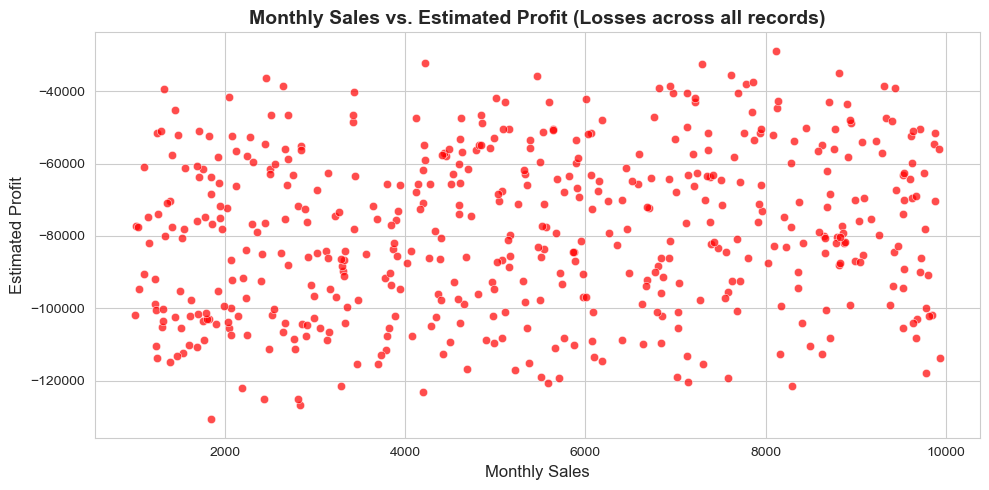

In [46]:
# 1. Highest estimated profit (least loss)
highest_prof = df.loc[df['Estimated_Profit'].idxmax()]
print(f'Highest Estimated Profit Warehouse (Least Loss): WH {highest_prof["Warehouse_ID"]} ({highest_prof["Location"]}) with {highest_prof["Estimated_Profit"]:,}')

# 2. Highest profit margin
df['Profit_Margin'] = df['Estimated_Profit'] / df['Monthly_Sales']
highest_margin = df.loc[df['Profit_Margin'].idxmax()]
print(f'Highest Profit Margin Warehouse: WH {highest_margin["Warehouse_ID"]} ({highest_margin["Location"]}) with {highest_margin["Profit_Margin"]*100:.2f}% margin')

# 3. Sales vs Profit relationship
corr_sales_profit = df['Monthly_Sales'].corr(df['Estimated_Profit'])
print(f'Correlation between Sales and Profit: {corr_sales_profit:.4f}')
print('Is high sales associated with high profits? No, they are uncorrelated/negatively correlated because total costs are much larger than sales.')

# 4. High costs but low profits (Top 3)
print('\nWarehouses with High Costs and Extremely Low Profits (Top Losses):')
high_cost_low_prof = df.sort_values(by=['Total_Cost', 'Estimated_Profit'], ascending=[False, True]).head(3)
for idx, row in high_cost_low_prof.iterrows():
    print(f'   - WH {row["Warehouse_ID"]} ({row["Location"]}) | Cost: {row["Total_Cost"]:,} | Profit: {row["Estimated_Profit"]:,}')

# 5. Financial efficiency (Sales / Total Cost)
df['Fin_Efficiency'] = df['Monthly_Sales'] / df['Total_Cost']
most_eff_wh = df.loc[df['Fin_Efficiency'].idxmax()]
print(f'\nMost Financially Efficient Warehouse (Sales-to-Cost): WH {most_eff_wh["Warehouse_ID"]} ({most_eff_wh["Location"]}) at {most_eff_wh["Fin_Efficiency"]:.4f}')

# Visual 6: Sales vs Profit Scatter
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Monthly_Sales', y='Estimated_Profit', alpha=0.7, color='red')
plt.title('Monthly Sales vs. Estimated Profit (Losses across all records)', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Sales', fontsize=12)
plt.ylabel('Estimated Profit', fontsize=12)
plt.tight_layout()
plt.show()


#### **Section 7: Risk Analysis (Stockout & Operational Risk)**
1. Which warehouse has the highest stockout risk?
2. Which warehouse has the highest risk score?
3. Which locations are most vulnerable to stock shortages?
4. How does lead time affect stockout risk?
5. Which warehouses require immediate inventory intervention?


Highest Stockout Risk Warehouse: WH WH244 (Houston) | Risk = 25
Highest Risk Score Warehouse: WH WH442 (Chicago) | Risk Score = 78.20

Average Stockout Risk by Location:
   - Houston: 16.27
   - New York: 16.00
   - Dallas: 15.94
   - Chicago: 15.11
   - Seattle: 15.07
   - Atlanta: 14.80
   - San Francisco: 14.50
   - Los Angeles: 14.19
   - Miami: 14.04
   - Denver: 13.72

Correlation between Lead Time and Stockout Risk: -0.0164

Top 3 Warehouses requiring Immediate Inventory Intervention:
   - WH WH211 (Dallas) | Risk: 24 | Understocked Gap: 4575 units
   - WH WH438 (Chicago) | Risk: 21 | Understocked Gap: 4509 units
   - WH WH343 (Denver) | Risk: 21 | Understocked Gap: 4015 units


C:\Users\sujal_sahu\AppData\Local\Temp\ipykernel_7124\2097955736.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_risk.values, y=loc_risk.index, palette='autumn')


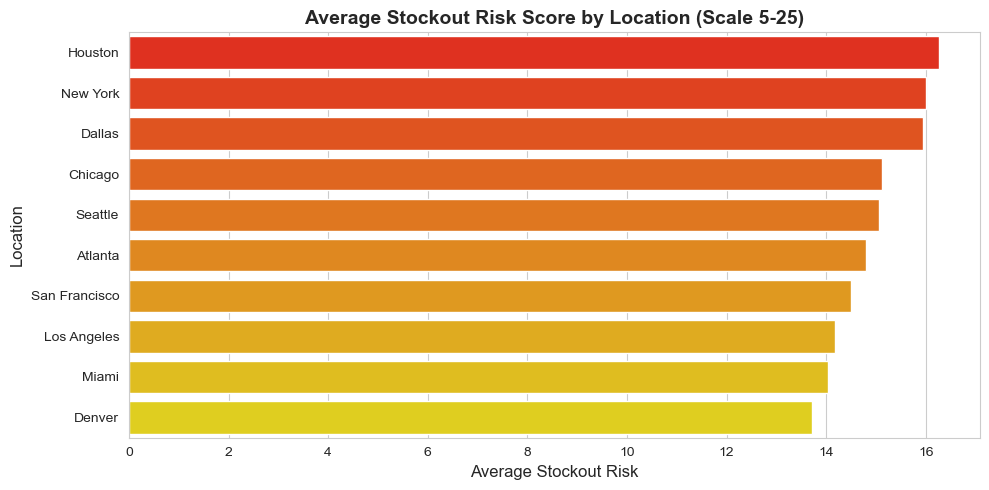

In [47]:
# 1. Highest stockout risk
highest_sor = df.loc[df['Stockout_Risk'].idxmax()]
print(f'Highest Stockout Risk Warehouse: WH {highest_sor["Warehouse_ID"]} ({highest_sor["Location"]}) | Risk = {highest_sor["Stockout_Risk"]}')

# 2. Highest risk score
highest_rs = df.loc[df['Risk_Score'].idxmax()]
print(f'Highest Risk Score Warehouse: WH {highest_rs["Warehouse_ID"]} ({highest_rs["Location"]}) | Risk Score = {highest_rs["Risk_Score"]:.2f}')

# 3. Locations vulnerable to shortage
print('\nAverage Stockout Risk by Location:')
loc_risk = df.groupby('Location')['Stockout_Risk'].mean().sort_values(ascending=False)
for loc, val in loc_risk.items():
    print(f'   - {loc}: {val:.2f}')

# 4. Lead time vs stockout risk
corr_lead_risk = df['Lead_Time_Days'].corr(df['Stockout_Risk'])
print(f'\nCorrelation between Lead Time and Stockout Risk: {corr_lead_risk:.4f}')

# 5. Intervention required (High Stockout Risk & negative Demand Gap / understocked)
print('\nTop 3 Warehouses requiring Immediate Inventory Intervention:')
intervention = df[(df['Stockout_Risk'] > 15) & (df['Demand_Gap'] > 0)].sort_values(by='Demand_Gap', ascending=False).head(3)
for idx, row in intervention.iterrows():
    print(f'   - WH {row["Warehouse_ID"]} ({row["Location"]}) | Risk: {row["Stockout_Risk"]} | Understocked Gap: {row["Demand_Gap"]} units')

# Visual 7: Stockout Risk by Location
plt.figure(figsize=(10, 5))
sns.barplot(x=loc_risk.values, y=loc_risk.index, palette='autumn')
plt.title('Average Stockout Risk Score by Location (Scale 5-25)', fontsize=14, fontweight='bold')
plt.xlabel('Average Stockout Risk', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.tight_layout()
plt.show()


#### **Section 8: Supplier Performance (Supply Chain Analysis)**
1. Which supplier has the longest lead time?
2. Which supplier serves the most warehouses?
3. Which suppliers contribute to delivery delays?
4. Which supplier is most reliable?


Supplier with Longest Lead Time: S105 | Avg Lead Time = 10.00 days
Supplier serving Most Warehouses: S219 serves 4 unique warehouses

Suppliers contributing to Delivery Delays (Avg Shipping Time):
   - S998: Avg shipping time = 7.00 days
   - S153: Avg shipping time = 7.00 days
   - S930: Avg shipping time = 7.00 days

Most Reliable Supplier (Shortest Lead Time & Low Return Rate): S415
   - Avg Lead Time: 2.00 days
   - Avg Return Rate: 1.17%


C:\Users\sujal_sahu\AppData\Local\Temp\ipykernel_7124\649303705.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('Supplier_ID')['Lead_Time_Days'].mean().reset_index().sort_values(by='Lead_Time_Days', ascending=False).head(15),


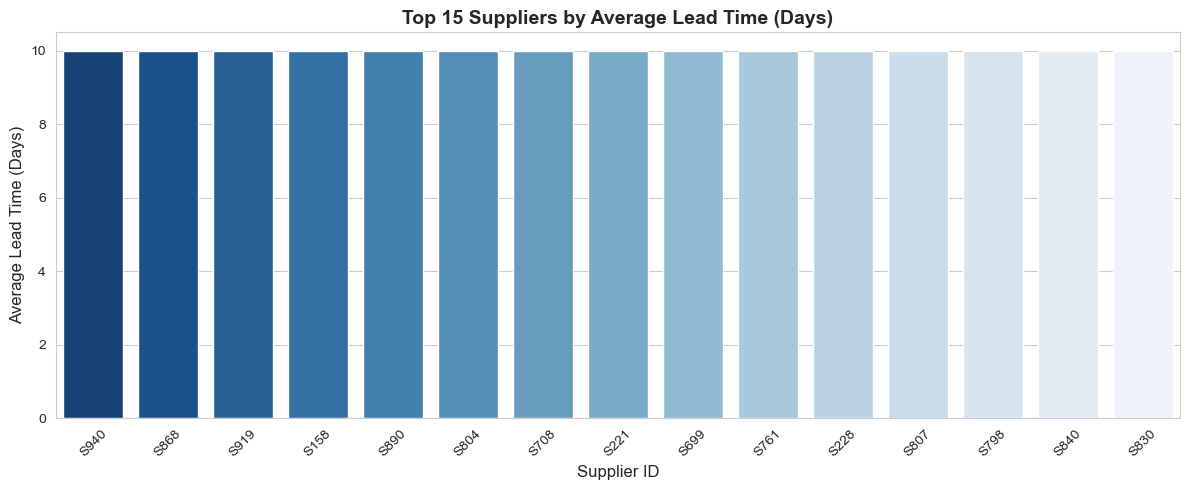

In [48]:
# 1. Longest lead time supplier
sup_lead = df.groupby('Supplier_ID')['Lead_Time_Days'].mean()
print(f'Supplier with Longest Lead Time: {sup_lead.idxmax()} | Avg Lead Time = {sup_lead.max():.2f} days')

# 2. Supplier serving most warehouses
sup_wh = df.groupby('Supplier_ID')['Warehouse_ID'].nunique()
print(f'Supplier serving Most Warehouses: {sup_wh.idxmax()} serves {sup_wh.max()} unique warehouses')

# 3. Suppliers contributing to delays
print('\nSuppliers contributing to Delivery Delays (Avg Shipping Time):')
sup_delays = df.groupby('Supplier_ID')['Shipping_Time_Days'].mean().sort_values(ascending=False).head(3)
for sup, val in sup_delays.items():
    print(f'   - {sup}: Avg shipping time = {val:.2f} days')

# 4. Most reliable supplier
supplier_metrics = df.groupby('Supplier_ID').agg({
    'Lead_Time_Days': 'mean',
    'Return_Rate': 'mean'
})
supplier_metrics['Score'] = (supplier_metrics['Lead_Time_Days'] / supplier_metrics['Lead_Time_Days'].max() + 
                            supplier_metrics['Return_Rate'] / supplier_metrics['Return_Rate'].max())
reliable_sup = supplier_metrics['Score'].idxmin()
print(f'\nMost Reliable Supplier (Shortest Lead Time & Low Return Rate): {reliable_sup}')
print(f'   - Avg Lead Time: {supplier_metrics.loc[reliable_sup, "Lead_Time_Days"]:.2f} days')
print(f'   - Avg Return Rate: {supplier_metrics.loc[reliable_sup, "Return_Rate"]:.2f}%')

# Visual 8: Supplier Lead Time Comparison
plt.figure(figsize=(12, 5))
sns.barplot(data=df.groupby('Supplier_ID')['Lead_Time_Days'].mean().reset_index().sort_values(by='Lead_Time_Days', ascending=False).head(15), 
            x='Supplier_ID', y='Lead_Time_Days', palette='Blues_r')
plt.title('Top 15 Suppliers by Average Lead Time (Days)', fontsize=14, fontweight='bold')
plt.xlabel('Supplier ID', fontsize=12)
plt.ylabel('Average Lead Time (Days)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### **Section 9: Customer Satisfaction (Service Quality)**
1. Does customer rating affect sales?
2. Which warehouse has the highest customer ratings?
3. Which product category has the highest return rate?
4. Do warehouses with faster deliveries receive better ratings?
5. Does return rate negatively impact profit?


Correlation between Rating and Sales: 0.0090 (indicating no/negligible direct relationship)
Warehouse with Highest Avg Customer Rating: WH WH354 (Atlanta) | Rating = 5.00
Product Category with Highest Return Rate: Electronics | Avg Return = 5.70%
Correlation between Delivery Cycle Time and Customer Rating: 0.0206
Correlation between Return Rate and Profit: -0.0449


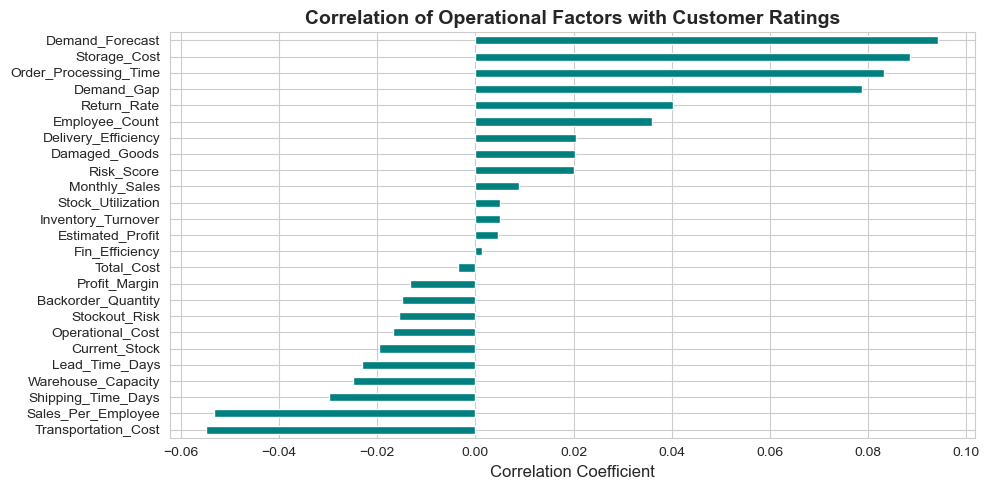

In [49]:
# 1. Rating vs sales
corr_rating_sales = df['Customer_Rating'].corr(df['Monthly_Sales'])
print(f'Correlation between Rating and Sales: {corr_rating_sales:.4f} (indicating no/negligible direct relationship)')

# 2. Highest ratings warehouse
high_rating_wh = df.groupby(['Warehouse_ID', 'Location'])['Customer_Rating'].mean().idxmax()
print(f'Warehouse with Highest Avg Customer Rating: WH {high_rating_wh[0]} ({high_rating_wh[1]}) | Rating = {df.groupby(["Warehouse_ID", "Location"])["Customer_Rating"].mean().max():.2f}')

# 3. Highest return rate category
cat_return = df.groupby('Product_Category', observed=False)['Return_Rate'].mean()
print(f'Product Category with Highest Return Rate: {cat_return.idxmax()} | Avg Return = {cat_return.max():.2f}%')

# 4. Delivery speed vs ratings
corr_del_rating = df['Delivery_Efficiency'].corr(df['Customer_Rating'])
print(f'Correlation between Delivery Cycle Time and Customer Rating: {corr_del_rating:.4f}')

# 5. Return rate vs profit
corr_return_profit = df['Return_Rate'].corr(df['Estimated_Profit'])
print(f'Correlation between Return Rate and Profit: {corr_return_profit:.4f}')

# Visual 9: Customer Rating Correlation Bar Chart
plt.figure(figsize=(10, 5))
corrs = df.select_dtypes(include=['int64', 'float64']).corr()['Customer_Rating'].sort_values()
corrs.drop('Customer_Rating').plot(kind='barh', color='teal')
plt.title('Correlation of Operational Factors with Customer Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.tight_layout()
plt.show()


#### **Section 10: Workforce Productivity (Employee Efficiency)**
1. Which warehouse has the highest sales per employee?
2. Which warehouse has the highest profit per employee?
3. Does employee count influence sales?
4. Are larger workforces more efficient?


Highest Sales per Employee: WH WH168 (Atlanta) | 1934.80 per employee
Highest Profit per Employee (Least Loss): WH WH156 (Los Angeles) | -356.51 per employee
Correlation between Employee Count and Monthly Sales: 0.0422
Correlation between Workforce Size and Sales per Employee: -0.6018


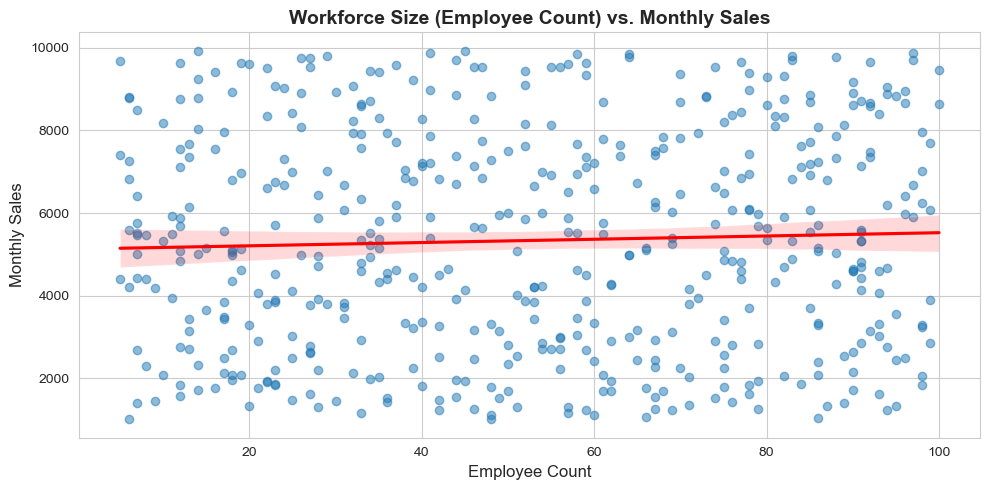

In [50]:
# 1. Highest sales per employee
df['Sales_Per_Employee'] = df['Monthly_Sales'] / df['Employee_Count']
highest_spe_wh = df.loc[df['Sales_Per_Employee'].idxmax()]
print(f'Highest Sales per Employee: WH {highest_spe_wh["Warehouse_ID"]} ({highest_spe_wh["Location"]}) | {highest_spe_wh["Sales_Per_Employee"]:.2f} per employee')

# 2. Highest profit per employee (least loss)
df['Profit_Per_Employee'] = df['Estimated_Profit'] / df['Employee_Count']
highest_ppe_wh = df.loc[df['Profit_Per_Employee'].idxmax()]
print(f'Highest Profit per Employee (Least Loss): WH {highest_ppe_wh["Warehouse_ID"]} ({highest_ppe_wh["Location"]}) | {highest_ppe_wh["Profit_Per_Employee"]:.2f} per employee')

# 3. Employee count vs Sales
corr_emp_sales = df['Employee_Count'].corr(df['Monthly_Sales'])
print(f'Correlation between Employee Count and Monthly Sales: {corr_emp_sales:.4f}')

# 4. Larger workforces vs efficiency (Sales per Employee)
corr_emp_efficiency = df['Employee_Count'].corr(df['Sales_Per_Employee'])
print(f'Correlation between Workforce Size and Sales per Employee: {corr_emp_efficiency:.4f}')

plt.figure(figsize=(10, 5))
sns.regplot(data=df, x='Employee_Count', y='Monthly_Sales', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Workforce Size (Employee Count) vs. Monthly Sales', fontsize=14, fontweight='bold')
plt.xlabel('Employee Count', fontsize=12)
plt.ylabel('Monthly Sales', fontsize=12)
plt.tight_layout()
plt.show()


The scatter plot shows a weak positive correlation between employee count and monthly sales. Although warehouses with more employees tend to achieve slightly higher sales, the large spread of data points indicates that workforce size alone does not strongly influence sales performance. Other operational and market factors have a greater impact.

#### **Section 11: Correlation (Relationship Analysis)**
1. What factors most strongly influence monthly sales?
2. What factors influence estimated profit?
3. Is inventory turnover related to sales?
4. Does delivery efficiency affect customer ratings?
5. Does lead time impact stockout risk?
6. Does demand forecast correlate with sales?


Correlation coefficients with Monthly Sales:
Monthly_Sales         1.000000
Fin_Efficiency        0.836115
Profit_Margin         0.783147
Inventory_Turnover    0.584028
Sales_Per_Employee    0.366095
Name: Monthly_Sales, dtype: float64

Correlation coefficients with Estimated Profit:
Estimated_Profit    1.000000
Total_Cost         -0.993045
Operational_Cost   -0.938558
Fin_Efficiency      0.605119
Profit_Margin       0.452656
Name: Estimated_Profit, dtype: float64

Correlation between Inventory Turnover and Sales: 0.5840
Correlation between Delivery Efficiency and Customer Rating: 0.0206
Correlation between Lead Time and Stockout Risk: -0.0164
Correlation between Demand Forecast and Monthly Sales: 0.0266


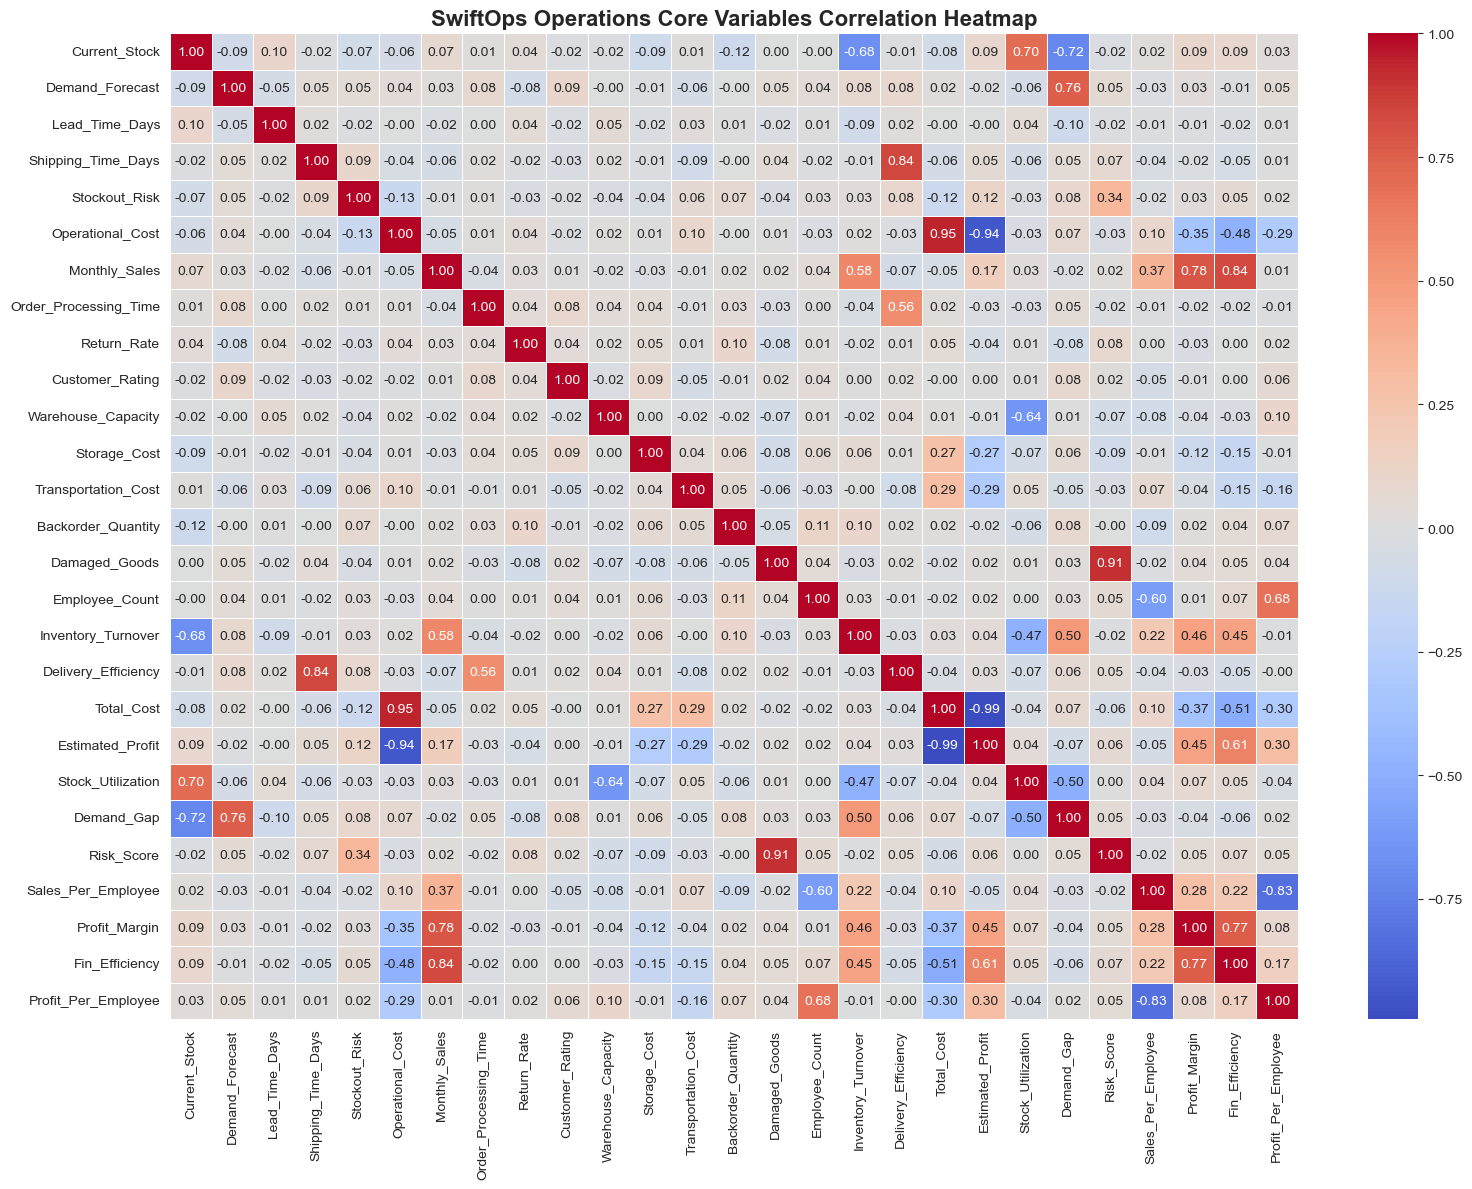

In [51]:
print('Correlation coefficients with Monthly Sales:')
print(df.select_dtypes(include=['int64', 'float64']).corr()['Monthly_Sales'].sort_values(key=abs, ascending=False).head(5))

print('\nCorrelation coefficients with Estimated Profit:')
print(df.select_dtypes(include=['int64', 'float64']).corr()['Estimated_Profit'].sort_values(key=abs, ascending=False).head(5))

print(f'\nCorrelation between Inventory Turnover and Sales: {df["Inventory_Turnover"].corr(df["Monthly_Sales"]):.4f}')
print(f'Correlation between Delivery Efficiency and Customer Rating: {df["Delivery_Efficiency"].corr(df["Customer_Rating"]):.4f}')
print(f'Correlation between Lead Time and Stockout Risk: {df["Lead_Time_Days"].corr(df["Stockout_Risk"]):.4f}')
print(f'Correlation between Demand Forecast and Monthly Sales: {df["Demand_Forecast"].corr(df["Monthly_Sales"]):.4f}')

# Visual 11: Correlation Heatmap
plt.figure(figsize=(16, 12))
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('SwiftOps Operations Core Variables Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
